Model Eğitimi Başlıyor...

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9601 - loss: 0.1330 - val_accuracy: 0.9819 - val_loss: 0.0536
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9871 - loss: 0.0428 - val_accuracy: 0.9886 - val_loss: 0.0336
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9905 - loss: 0.0299 - val_accuracy: 0.9884 - val_loss: 0.0331
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9937 - loss: 0.0206 - val_accuracy: 0.9857 - val_loss: 0.0463
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9954 - loss: 0.0150 - val_accuracy: 0.9914 - val_loss: 0.0273


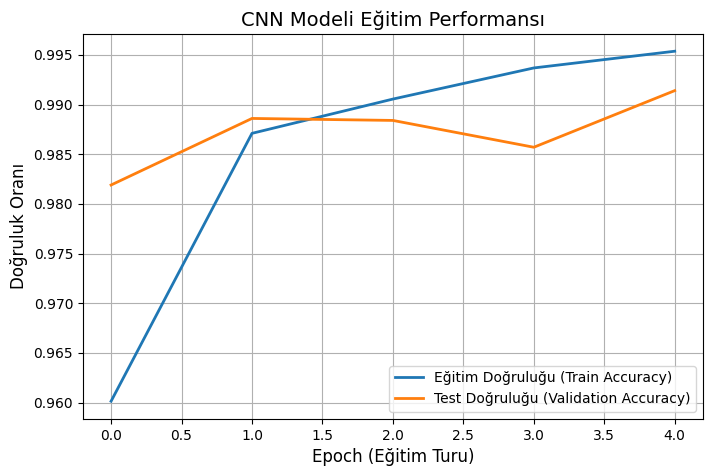

In [2]:
# 1. GEREKLİ KÜTÜPHANELERİ YÜKLÜYORUZ
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 2. VERİ SETİNİ YÜKLEME VE HAZIRLAMA (MNIST)
# Keras üzerinden veri setini çekiyoruz ve otomatik olarak Eğitim/Test diye ayırıyoruz.
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Normalizasyon: Pikseller 0-255 arası değer alır. Ağın daha hızlı öğrenmesi için
# bütün pikselleri 255'e bölerek 0 ile 1 arasına çekiyoruz. (Mühendislik optimizasyonu)
train_images = train_images / 255.0
test_images = test_images / 255.0

# 3. CNN MODEL MİMARİSİNİ İNŞA ETME
model = models.Sequential()

# 1. Evrişim Katmanı: 32 adet 3x3'lük filtre kullanıyoruz.
# Giriş boyutu: 28x28 piksel ve 1 kanal (Siyah-Beyaz)
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# 1. Havuzlama Katmanı: Veriyi 2x2 boyutunda küçülterek en önemli özellikleri seçiyoruz.
model.add(layers.MaxPooling2D((2, 2)))

# 2. Evrişim Katmanı: Derinleştikçe filtre sayısını artırıyoruz (64 filtre).
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# 2. Havuzlama Katmanı: Veriyi tekrar yarı yarıya küçültüyoruz.
model.add(layers.MaxPooling2D((2, 2)))

# 4. SINIFLANDIRMA (KARAR) AŞAMASINA GEÇİŞ
# Matris halindeki veriyi düz bir vektör (liste) haline getiriyoruz.
model.add(layers.Flatten())

# Gizli Katman: 128 nöronluk klasik bir yapay sinir ağı katmanı ekliyoruz.
model.add(layers.Dense(128, activation='relu'))

# Çıkış Katmanı: 0'dan 9'a kadar 10 rakam olduğu için 10 nöron koyuyoruz.
# Softmax fonksiyonu bize her rakam için bir olasılık yüzdesi verir.
model.add(layers.Dense(10, activation='softmax'))

# 5. MODELİ DERLEME VE EĞİTME
# Modeli, ağırlıklarını güncelleyecek algoritmalarla derliyoruz.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Model Eğitimi Başlıyor...\n")
# Modelin eğitimi: Bütün veriyi 5 kez (epochs=5) baştan sona görecek.
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

# 6. SONUÇLARI GÖRSELLEŞTİRME (GRAFİK)
# Raporun 5.3 kısmına koyacağın doğruluk grafiğini çizdiriyoruz.
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu (Train Accuracy)', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Test Doğruluğu (Validation Accuracy)', linewidth=2)
plt.title('CNN Modeli Eğitim Performansı', fontsize=14)
plt.xlabel('Epoch (Eğitim Turu)', fontsize=12)
plt.ylabel('Doğruluk Oranı', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True)
plt.show()